# Vietnamese Auto Parts - Demand Forecasting
**Goal:** Dự đoán daily sales quantity cho 56 ngày tiếp theo (F1–F56) trên 15,972 SKUs  
**Metric:** WRMSSE (Weighted RMSSE, weighted by profit per SKU)  
**Strategy:** LightGBM với lag features + rolling stats + calendar features

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Install lightgbm if needed
try:
    import lightgbm as lgb
    print('LightGBM version:', lgb.__version__)
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'lightgbm', '-q'])
    import lightgbm as lgb

from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (14, 5)

print('All libraries loaded ✓')

LightGBM version: 4.6.0
All libraries loaded ✓


## 2. Load Data

In [2]:
# Thay đổi đường dẫn nếu chạy trên môi trường khác
TRAIN_PATH = 'data/train.csv'
SAMPLE_PATH = 'data/sample_submission.csv'

train_raw = pd.read_csv(TRAIN_PATH, low_memory=False)
sample_sub = pd.read_csv(SAMPLE_PATH)

print(f'Train shape: {train_raw.shape}')
print(f'Sample submission shape: {sample_sub.shape}')
print(f'\nTrain columns: {train_raw.columns.tolist()}')
train_raw.head()

Train shape: (711980, 8)
Sample submission shape: (31944, 29)

Train columns: ['Date', 'Stt', 'ItemCode', 'Quantity', 'UnitPrice', 'SalesAmount', 'Unit Cost', 'Cost Amount']


,Date,Stt,ItemCode,Quantity,UnitPrice,SalesAmount,Unit Cost,Cost Amount
0,2020-11-17,2000004,SKU-08063,12,242700,2184300,"123559,1",1482709
1,2020-11-17,2000003,SKU-09458,600,"131818,1818",79090909,110000,66000000
2,2020-11-18,2000007,SKU-08062,6,230000,940909,101000,606000
3,2020-11-18,2000006,SKU-09458,240,270000,44181818,110000,26400000
4,2020-11-18,2000005,SKU-09458,240,270000,44181818,110000,26400000


## 3. Data Preprocessing

In [3]:
# 3.1 Parse & clean train
df = train_raw.copy()
df['Date'] = pd.to_datetime(df['Date'])
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce').fillna(0)

# Parse SalesAmount và CostAmount (remove commas)
def parse_amount(col):
    return pd.to_numeric(
        col.astype(str).str.replace(',', '', regex=False), errors='coerce'
    ).fillna(0)

df['SalesAmount'] = parse_amount(df['SalesAmount'])
df['CostAmount']  = parse_amount(df['Cost Amount'])

# Parse UnitPrice and UnitCost (remove commas and convert to numeric)
df['UnitPrice'] = parse_amount(df['UnitPrice'])
df['Unit Cost'] = parse_amount(df['Unit Cost'])

print('Date range:', df['Date'].min(), '->', df['Date'].max())
print('Negative Quantity (returns):', (df['Quantity'] < 0).sum())
print('Unique SKUs:', df['ItemCode'].nunique())

Date range: 2020-11-17 00:00:00 -> 2025-09-05 00:00:00
Negative Quantity (returns): 37434
Unique SKUs: 15972


In [4]:
# 3.2 Compute profit weights
# profit_i = sum(SalesAmount - CostAmount) over training set
profit_df = df.groupby('ItemCode').apply(
    lambda x: (x['SalesAmount'] - x['CostAmount']).sum()
).reset_index()
profit_df.columns = ['ItemCode', 'profit']

# Negative profit -> weight 0
profit_df['profit'] = profit_df['profit'].clip(lower=0)
total_profit = profit_df['profit'].sum()
if total_profit > 0:
    profit_df['weight'] = profit_df['profit'] / total_profit
else:
    profit_df['weight'] = 1.0 / len(profit_df)

print('SKUs with positive profit:', (profit_df['profit'] > 0).sum())
print('SKUs with zero weight:', (profit_df['profit'] == 0).sum())
profit_df.sort_values('weight', ascending=False).head(10)

SKUs with positive profit: 10757
SKUs with zero weight: 5215


,ItemCode,profit,weight
2,SKU-00003,16700681088,0.134901
1,SKU-00002,8012686409,0.064723
4,SKU-00005,2243340437,0.018121
12229,SKU-12534,1215803793,0.009821
8354,SKU-08589,1146483691,0.009261
12230,SKU-12537,1106799793,0.008940
315,SKU-00324,869747181,0.007025
4152,SKU-04268,864562072,0.006984
6601,SKU-06780,853592011,0.006895
3,SKU-00004,835996756,0.006753


In [5]:
# 3.3 Aggregate to daily SKU level
# Giữ nguyên returns (quantity âm) → gộp lại thành net daily quantity
# Keep SalesAmount/CostAmount so price features can be computed later.
daily = (
    df.groupby(['ItemCode', 'Date'])
    .agg(
        Quantity=('Quantity', 'sum'),
        AvgUnitPrice=('UnitPrice', 'mean'),
        AvgUnitCost=('Unit Cost', 'mean'),
    )
    .reset_index()
 )

# 3.4 Create full date × SKU grid
all_skus = daily['ItemCode'].unique()
all_dates = pd.date_range(daily['Date'].min(), daily['Date'].max(), freq='D')

grid = pd.MultiIndex.from_product([all_skus, all_dates], names=['ItemCode','Date'])
daily_full = (
    daily.set_index(['ItemCode','Date'])
    .reindex(grid, fill_value=0)
    .reset_index()
 )
daily_full = daily_full.sort_values(['ItemCode','Date']).reset_index(drop=True)

print(f'Grid shape: {daily_full.shape}')
print(f'Date range: {daily_full["Date"].min()} -> {daily_full["Date"].max()}')

daily_full.head()

Grid shape: (28014888, 5)
Date range: 2020-11-17 00:00:00 -> 2025-09-05 00:00:00


,ItemCode,Date,Quantity,AvgUnitPrice,AvgUnitCost
0,SKU-00001,2020-11-17,0,0.0,0.0
1,SKU-00001,2020-11-18,0,0.0,0.0
2,SKU-00001,2020-11-19,0,0.0,0.0
3,SKU-00001,2020-11-20,0,0.0,0.0
4,SKU-00001,2020-11-21,0,0.0,0.0


## 4. Feature Engineering

In [6]:
# 4.1 Calendar features
daily_full['dayofweek']  = daily_full['Date'].dt.dayofweek
daily_full['month']      = daily_full['Date'].dt.month
daily_full['quarter']    = daily_full['Date'].dt.quarter
daily_full['weekofyear'] = daily_full['Date'].dt.isocalendar().week.astype(int)
# daily_full['year']       = daily_full['Date'].dt.year
daily_full['dayofmonth'] = daily_full['Date'].dt.day
daily_full['is_weekend'] = (daily_full['dayofweek'] >= 5).astype(int)

# Vietnamese Lunar New Year approximate windows (tháng 1-2 dương lịch)
# daily_full['is_tet_season'] = (
#     (daily_full['month'].isin([1, 2]))
# ).astype(int)

print('Calendar features added ✓')

Calendar features added ✓


In [7]:
# 4.2 Lag features
LAG_DAYS = [1, 7, 14, 28, 56]

for lag in LAG_DAYS:
    daily_full[f'lag_{lag}'] = (
        daily_full.groupby('ItemCode')['Quantity']
        .shift(lag)
    )

print('Lag features added ✓')

Lag features added ✓


In [8]:
# 4.3 Rolling mean/std features (shift 1 for recursive forecasting)
# With recursive prediction, we predict day-by-day and update lags natively,
# so shift(1) captures yesterday's momentum without data leakage.
ROLLING_WINDOWS = [7, 14, 28, 56]

for win in ROLLING_WINDOWS:
    shifted = daily_full.groupby('ItemCode')['Quantity'].shift(1)
    daily_full[f'roll_mean_{win}'] = (
        shifted.groupby(daily_full['ItemCode'])
        .transform(lambda x: x.rolling(win, min_periods=1).mean())
    )
ROLLING_WINDOWS_STD = [7, 56]
for win in ROLLING_WINDOWS_STD:
    daily_full[f'roll_std_{win}'] = (
        shifted.groupby(daily_full['ItemCode'])
        .transform(lambda x: x.rolling(win, min_periods=1).std().fillna(0))
    )

print('Rolling features added (shift=1 for recursive prediction) ✓')

Rolling features added (shift=1 for recursive prediction) ✓


In [9]:
# 4.4 SKU encode + merge profit weights
le = LabelEncoder()
daily_full['sku_enc'] = le.fit_transform(daily_full['ItemCode'])

daily_full = daily_full.merge(profit_df[['ItemCode','weight']], on='ItemCode', how='left')
daily_full['weight'] = daily_full['weight'].fillna(0)

print('SKU encoding + weights merged ✓')
daily_full.head()

SKU encoding + weights merged ✓


,ItemCode,Date,Quantity,AvgUnitPrice,AvgUnitCost,dayofweek,month,quarter,weekofyear,dayofmonth,...,lag_28,lag_56,roll_mean_7,roll_mean_14,roll_mean_28,roll_mean_56,roll_std_7,roll_std_56,sku_enc,weight
0,SKU-00001,2020-11-17,0,0.0,0.0,1,11,4,47,17,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0,0.000291
1,SKU-00001,2020-11-18,0,0.0,0.0,2,11,4,47,18,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0,0.000291
2,SKU-00001,2020-11-19,0,0.0,0.0,3,11,4,47,19,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0,0.000291
3,SKU-00001,2020-11-20,0,0.0,0.0,4,11,4,47,20,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0,0.000291
4,SKU-00001,2020-11-21,0,0.0,0.0,5,11,4,47,21,...,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0,0.000291


4.5 Intermittency feature

In [10]:
# 4.5 Intermittency (Sparsity) Features
# Use lagged quantity to avoid leakage (only past information).
qty_shifted = (
    daily_full.groupby('ItemCode')['Quantity']
    .shift(1)
    .fillna(0)
 )

# Zero-Sale Ratio: proportion of zero-sale days in last 28 days
daily_full['zero_sale_ratio_28'] = (
    qty_shifted.groupby(daily_full['ItemCode'])
    .transform(lambda x: (x == 0).rolling(28, min_periods=1).mean())
 )

# Days Since Last Sale: count days since Quantity > 0 (max 999 if never sold)
def days_since_last_sale(qty_series):
    result = []
    last_sale_idx = -1
    for idx, qty in enumerate(qty_series):
        if qty > 0:
            last_sale_idx = idx
        days = min(999, idx - last_sale_idx) if last_sale_idx >= 0 else 999
        result.append(days)
    return result

daily_full['days_since_last_sale'] = (
    qty_shifted.groupby(daily_full['ItemCode'])
    .transform(days_since_last_sale)
 )

print('Intermittency features added (lagged zero-sale ratio, days-since-last-sale) ✓')

Intermittency features added (lagged zero-sale ratio, days-since-last-sale) ✓


In [11]:
# 4.6 Target Encoding (Historical Aggregates) + 4.7 Price Features

# ==== TARGET ENCODING (Feature C) ====
# Compute on train dates only to prevent data leakage
train_cutoff = pd.Timestamp('2025-08-08')
train_for_encoding = daily_full[daily_full['Date'] <= train_cutoff]

# All-time avg sales by (ItemCode, dayofweek) using train dates only
target_enc_dayofweek = (
    train_for_encoding.groupby(['ItemCode', 'dayofweek'])['Quantity']
    .mean()
    .reset_index()
    .rename(columns={'Quantity': 'target_enc_dayofweek'})
 )

target_enc_month = (
    train_for_encoding.groupby(['ItemCode', 'month'])['Quantity']
    .mean()
    .reset_index()
    .rename(columns={'Quantity': 'target_enc_month'})
 )

# Left-join to both train and validation (prevents future leakage)
daily_full = daily_full.merge(target_enc_dayofweek, on=['ItemCode', 'dayofweek'], how='left').fillna(0)
daily_full = daily_full.merge(target_enc_month, on=['ItemCode', 'month'], how='left').fillna(0)

print('Target encoding features added (dayofweek & month averages) ✓')


Target encoding features added (dayofweek & month averages) ✓


In [12]:
# 4.8 Active Recently Flags, Sales Count, Velocity & EMA Features
# All use shifted quantity (lag-1) to prevent data leakage.
# Memory-optimised: int8/float32 dtypes, reuse existing roll_mean columns.

qty_shifted = (
    daily_full.groupby('ItemCode')['Quantity']
    .shift(1)
    .fillna(0)
)
had_sale = (qty_shifted > 0).astype(np.int8)

# ── Active Recently Flags (binary int8, ~27MB each) ──
# Was there ANY sale in the last N days?  Critical for intermittent-demand SKUs.
for win in [7, 28]:
    daily_full[f'active_last_{win}d'] = (
        had_sale
        .groupby(daily_full['ItemCode'])
        .transform(lambda x: x.rolling(win, min_periods=1).max())
        .astype(np.int8)
    )

# ── Sales Count Feature ──
# How many days had a sale in the last 28 days? (complements zero_sale_ratio_28)
daily_full['sale_days_28'] = (
    had_sale
    .groupby(daily_full['ItemCode'])
    .transform(lambda x: x.rolling(28, min_periods=1).sum())
    .astype(np.float64)
)

# ── Velocity Feature ──
# Short-term vs long-term demand ratio → detects acceleration/deceleration.
# Reuses existing roll_mean_7 / roll_mean_28 (already shifted, no leakage).
daily_full['velocity_7_28'] = np.where(
    daily_full['roll_mean_28'] > 0,
    daily_full['roll_mean_7'] / daily_full['roll_mean_28'],
    0.0,
).astype(np.float64)

# ── EMA Feature ──
# Exponential Moving Average (span=7 ≈ weekly half-life).
# Reacts faster to recent demand changes than simple rolling mean.
daily_full['ema_7'] = (
    qty_shifted
    .groupby(daily_full['ItemCode'])
    .transform(lambda x: x.ewm(span=7, min_periods=1).mean())
    .astype(np.float64)
)

# Clean up temp
del qty_shifted, had_sale

print('Active flags, sales count, velocity & EMA features added ✓')
print(f'New columns: active_last_7d, active_last_28d, sale_days_28, velocity_7_28, ema_7')
print(f'DataFrame shape: {daily_full.shape}')

Active flags, sales count, velocity & EMA features added ✓
New columns: active_last_7d, active_last_28d, sale_days_28, velocity_7_28, ema_7
DataFrame shape: (28014888, 33)


In [13]:
# ==== PRICE & COST FEATURES (Feature D) ====
# Use AvgUnitPrice / AvgUnitCost already in daily_full.
# Apply log1p transform to handle long-tailed price distributions.
# Many SKUs have very high prices (millions VND) while most are low,
# so log1p compresses the range and reduces outlier influence.

# --- Step 1: Shift raw prices by 1 day to avoid leakage ---
price_shifted = daily_full.groupby('ItemCode')['AvgUnitPrice'].shift(1).fillna(0)
cost_shifted  = daily_full.groupby('ItemCode')['AvgUnitCost'].shift(1).fillna(0)

# --- Step 2: Log-transformed price & cost (handles long-tail) ---
daily_full['log_price_lag1'] = np.log1p(price_shifted.clip(lower=0))
daily_full['log_cost_lag1']  = np.log1p(cost_shifted.clip(lower=0))

# --- Step 3: Profit margin (in log-space for robustness) ---
# log(price) - log(cost) ≈ log(price/cost), stable for extreme values
daily_full['log_profit_margin_lag1'] = (
    daily_full['log_price_lag1'] - daily_full['log_cost_lag1']
)

# --- Step 4: Rolling max price in log-space + discount ratio ---
daily_full['roll_max_log_price_56_lag1'] = (
    daily_full['log_price_lag1']
    .groupby(daily_full['ItemCode'])
    .transform(lambda x: x.rolling(56, min_periods=1).max())
    .fillna(0)
)

daily_full['log_price_discount_lag1'] = np.where(
    daily_full['roll_max_log_price_56_lag1'] != 0,
    daily_full['log_price_lag1'] / daily_full['roll_max_log_price_56_lag1'],
    1.0,
)

# --- Step 5: Rolling mean of log-price (smoothed price signal) ---
daily_full['roll_mean_log_price_28_lag1'] = (
    daily_full['log_price_lag1']
    .groupby(daily_full['ItemCode'])
    .transform(lambda x: x.rolling(28, min_periods=1).mean())
    .fillna(0)
)

# --- Step 6: Price volatility (std of log-price over 28d) ---
daily_full['log_price_volatility_28_lag1'] = (
    daily_full['log_price_lag1']
    .groupby(daily_full['ItemCode'])
    .transform(lambda x: x.rolling(28, min_periods=1).std())
    .fillna(0)
)

print('Price & cost features added (log-transformed for long-tail handling) ✓')


Price & cost features added (log-transformed for long-tail handling) ✓


In [14]:
daily_full.head()

,ItemCode,Date,Quantity,AvgUnitPrice,AvgUnitCost,dayofweek,month,quarter,weekofyear,dayofmonth,...,sale_days_28,velocity_7_28,ema_7,log_price_lag1,log_cost_lag1,log_profit_margin_lag1,roll_max_log_price_56_lag1,log_price_discount_lag1,roll_mean_log_price_28_lag1,log_price_volatility_28_lag1
0,SKU-00001,2020-11-17,0,0.0,0.0,1,11,4,47,17,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,SKU-00001,2020-11-18,0,0.0,0.0,2,11,4,47,18,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,SKU-00001,2020-11-19,0,0.0,0.0,3,11,4,47,19,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,SKU-00001,2020-11-20,0,0.0,0.0,4,11,4,47,20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,SKU-00001,2020-11-21,0,0.0,0.0,5,11,4,47,21,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## 4.8 Convert Data Types for Memory Optimization

In [14]:
# Convert dtypes to reduce memory usage
print('Converting data types for memory optimization...')

# Integer features → int8 or int16 (safe ranges for calendar/categorical features)
int_features = {
    'dayofweek': 'int8',       # 0-6
    'month': 'int8',           # 1-12
    'quarter': 'int8',         # 1-4
    'year': 'int16',           # year values
    'dayofmonth': 'int8',      # 1-31
    'is_weekend': 'int8',      # 0-1
    'is_tet_season': 'int8',   # 0-1
    'sku_enc': 'int16',        # 0-15971 (need at least int16)
    'days_since_last_sale': 'int16',  # 0-999
}

# Float features → float32 (sufficient precision for ML, half the memory of float64)
float_features = (
    ['profit_margin_lag1', 'price_discount_lag1', 'weight',
     'log_price_lag1', 'log_cost_lag1', 'log_profit_margin_lag1',
     'roll_max_log_price_56_lag1', 'log_price_discount_lag1',
     'roll_mean_log_price_28_lag1', 'log_price_volatility_28_lag1',
     'sale_days_28', 'lag_56', 'lag_14', 'roll_std_56', 'roll_std_7', 'AvgUnitPrice', 'AvgUnitCost']
)

# Convert integers
for col, dtype in int_features.items():
    if col in daily_full.columns:
        daily_full[col] = daily_full[col].astype(dtype)

# Convert floats
for col in float_features:
    if col in daily_full.columns:
        daily_full[col] = daily_full[col].astype('float32')

# Date column remains datetime64 (efficient storage)
print(f'Memory usage before: ~{daily_full.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
print(f'Data type conversions completed ✓')
print(f'\nData types after optimization:')
print(daily_full.dtypes)

Converting data types for memory optimization...
Memory usage before: ~6866.29 MB
Data type conversions completed ✓

Data types after optimization:
ItemCode                                object
Date                            datetime64[ns]
Quantity                                 int64
AvgUnitPrice                           float32
AvgUnitCost                            float32
dayofweek                                 int8
month                                     int8
quarter                                   int8
weekofyear                               int64
dayofmonth                                int8
is_weekend                                int8
lag_1                                  float64
lag_7                                  float64
lag_14                                 float32
lag_28                                 float64
lag_56                                 float32
roll_mean_7                            float64
roll_mean_14                           float64
roll_m

## 5. Train / Validation Split

In [15]:
# Cutoff: dùng 28 ngày cuối training làm validation (simulate leaderboard)
TRAIN_END   = pd.Timestamp('2025-08-08')  # training ends here
VAL_START   = pd.Timestamp('2025-08-09')  # validation 28 days
VAL_END     = pd.Timestamp('2025-09-05')  # last day of training data

FEATURE_COLS = (
    ['sku_enc', 'dayofweek', 'month', 'quarter', 'weekofyear',
     'dayofmonth', 'is_weekend']
    + [f'lag_{l}' for l in LAG_DAYS]
    + [f'roll_mean_{w}' for w in ROLLING_WINDOWS]
    + [f'roll_std_{w}' for w in ROLLING_WINDOWS_STD]
    + ['zero_sale_ratio_28', 'days_since_last_sale']
    + ['target_enc_dayofweek', 'target_enc_month']
    + ['log_profit_margin_lag1', 'log_price_discount_lag1']      # or log-transformed versions
    + ['active_last_7d', 'active_last_28d', 'sale_days_28',
       'velocity_7_28', 'ema_7']
)


TARGET = 'Quantity'

train_df = daily_full[daily_full['Date'] <= TRAIN_END].dropna(subset=FEATURE_COLS)
val_df   = daily_full[(daily_full['Date'] >= VAL_START) & (daily_full['Date'] <= VAL_END)].dropna(subset=FEATURE_COLS)

X_train, y_train = train_df[FEATURE_COLS], train_df[TARGET].clip(lower=0)
X_val,   y_val   = val_df[FEATURE_COLS],   val_df[TARGET].clip(lower=0)

print(f'Train samples: {len(X_train):,}')
print(f'Val samples:   {len(X_val):,}')

Train samples: 27,567,672
Val samples:   447,216


## 6. Train LightGBM Model

In [16]:
params = {
    'objective':       'tweedie',   # MAE loss — robust to outliers
    'tweedie_variance_power': 1.1,
    'metric':          'rmse',
    'num_leaves':      127,
    'learning_rate':   0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq':    5,
    'min_child_samples': 20,
    'lambda_l1':       0.1,
    'lambda_l2':       0.1,
    'n_jobs':          -1,
    'verbose':         -1,
    'seed':            42,
}

w_train = train_df['weight']
w_val = val_df['weight']
dtrain = lgb.Dataset(X_train, label=y_train, weight=w_train)
dval   = lgb.Dataset(X_val,   label=y_val, reference=dtrain, weight=w_val)

model = lgb.train(
    params,
    dtrain,
    num_boost_round=2000,
    valid_sets=[dtrain, dval],
    valid_names=['train', 'val'],
    callbacks=[
        lgb.early_stopping(100, verbose=True),
        lgb.log_evaluation(200),
    ],
)

print(f'\nBest iteration: {model.best_iteration}')

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[35]	train's rmse: 25.5121	val's rmse: 16.2245

Best iteration: 35


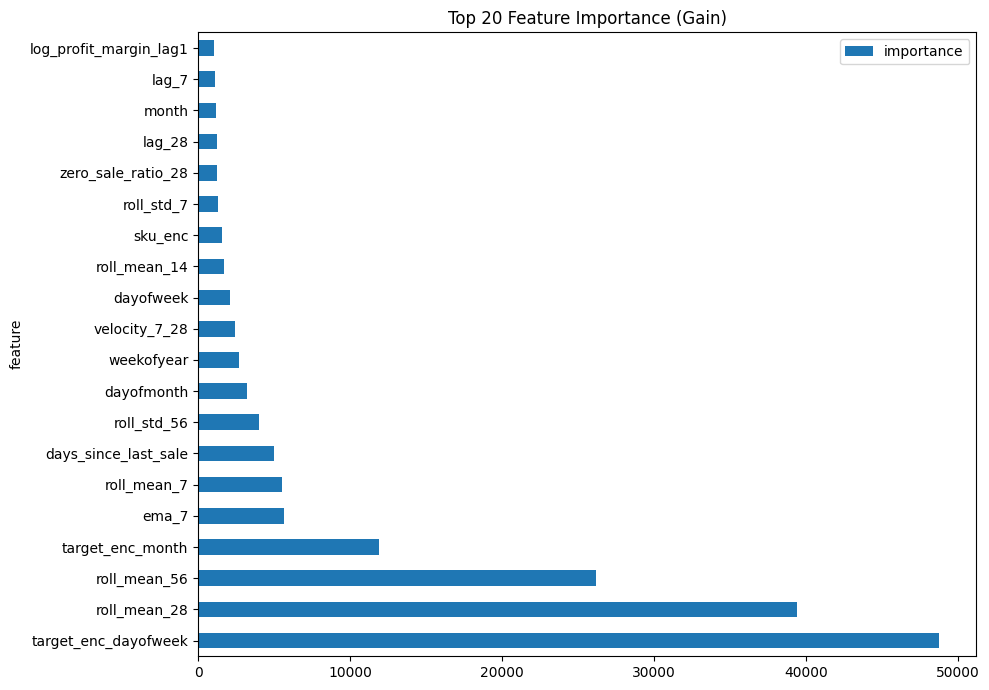

In [17]:
# Feature importance
fi = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': model.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False)

fi.head(20).plot.barh(x='feature', y='importance', figsize=(10,7))
plt.title('Top 20 Feature Importance (Gain)')
plt.tight_layout()
plt.show()

## 7. WRMSSE Evaluation on Validation Set

In [18]:
def compute_wrmsse(val_df, preds, train_df, weight_df):
    
    'Tính WRMSSE theo đúng công thức của competition.'
    
    val_df = val_df.copy()
    val_df['pred'] = np.maximum(preds, 0)  # clamp at 0
    
    # Denominator: mean squared naive forecast trên training
    def naive_scale(series):
        """MSE of naive 1-step forecast on training series."""
        diffs = np.diff(series)
        if len(diffs) == 0:
            return 1.0
        mse = np.mean(diffs ** 2)
        return mse if mse > 0 else 1.0
    
    train_scales = (
        train_df.groupby('ItemCode')['Quantity']
        .apply(lambda x: naive_scale(x.values))
        .reset_index()
    )
    train_scales.columns = ['ItemCode', 'scale']
    
    # Per-SKU MSE on validation
    sku_mse = (
        val_df.groupby('ItemCode')
        .apply(lambda g: np.mean((g['Quantity'] - g['pred'])**2))
        .reset_index()
    )
    sku_mse.columns = ['ItemCode', 'mse']
    
    # Merge and compute RMSSE per SKU
    merged = sku_mse.merge(train_scales, on='ItemCode').merge(weight_df, on='ItemCode')
    merged['rmsse'] = np.sqrt(merged['mse'] / merged['scale'])
    
    # Weighted average
    wrmsse = (merged['rmsse'] * merged['weight']).sum()
    return wrmsse, merged


val_preds = model.predict(X_val, num_iteration=model.best_iteration)
val_df_copy = val_df.copy()

wrmsse_score, sku_scores = compute_wrmsse(
    val_df_copy, val_preds,
    train_df, profit_df[['ItemCode','weight']]
)
print(f'\n Validation WRMSSE: {wrmsse_score:.4f}')
print('(Lower is better; < 1.0 means better than naive forecast)')


 Validation WRMSSE: 1.2525
(Lower is better; < 1.0 means better than naive forecast)


In [ ]:
# Top SKUs by weight & their RMSSE
top_sku_scores = sku_scores.sort_values('weight', ascending=False).head(20)
print('Top 20 SKUs by profit weight:')
print(top_sku_scores[['ItemCode','weight','rmsse']].to_string(index=False))

## 8. Generate Predictions for Submission

Dùng **recursive forecasting**: dự đoán từng ngày một, dùng prediction của ngày trước làm lag cho ngày tiếp theo.

In [ ]:
# Forecast start date
import time

FORECAST_START = pd.Timestamp('2025-09-06')
FORECAST_DAYS  = 56  # F1 to F56

t_setup = time.perf_counter()
print('Forecast setup: building matrices...')

# Keep the full history to compute lags
history = daily_full[daily_full['Date'] <= pd.Timestamp('2025-09-05')].copy()
history_sorted = history.sort_values(['ItemCode','Date'])

# Pivot to wide matrices for fast vectorized access
qty_pivot = (
    history_sorted.pivot(index='ItemCode', columns='Date', values='Quantity')
    .fillna(0)
 )
price_pivot = (
    history_sorted.pivot(index='ItemCode', columns='Date', values='UnitPrice_calc')
    .fillna(0)
 )
cost_pivot = (
    history_sorted.pivot(index='ItemCode', columns='Date', values='UnitCost_calc')
    .fillna(0)
 )

skus = qty_pivot.index.to_numpy()
dates = qty_pivot.columns.to_numpy()
n_skus = len(skus)
n_hist = len(dates)

print(f'  SKUs: {n_skus:,}')
print(f'  History days: {n_hist:,}')

# Preallocate extended history (history + forecast horizon)
total_len = n_hist + FORECAST_DAYS
qty_ext = np.zeros((n_skus, total_len), dtype=float)
price_ext = np.zeros((n_skus, total_len), dtype=float)
cost_ext = np.zeros((n_skus, total_len), dtype=float)
qty_ext[:, :n_hist] = qty_pivot.to_numpy()
price_ext[:, :n_hist] = price_pivot.to_numpy()
cost_ext[:, :n_hist] = cost_pivot.to_numpy()

last_price = price_ext[:, n_hist - 1] if n_hist > 0 else np.zeros(n_skus)
last_cost = cost_ext[:, n_hist - 1] if n_hist > 0 else np.zeros(n_skus)

# Target encoding matrices (aligned to SKU order)
enc_dow_mat = (
    target_enc_dayofweek
    .pivot(index='ItemCode', columns='dayofweek', values='target_enc_dayofweek')
    .reindex(index=skus, columns=range(7), fill_value=0)
    .to_numpy()
 )
enc_month_mat = (
    target_enc_month
    .pivot(index='ItemCode', columns='month', values='target_enc_month')
    .reindex(index=skus, columns=range(1, 13), fill_value=0)
    .to_numpy()
 )

# Precompute initial days-since-last-sale from history
last_pos = np.full(n_skus, -1, dtype=int)
for t in range(n_hist):
    pos = qty_ext[:, t] > 0
    last_pos[pos] = t
dsls = np.where(last_pos >= 0, (n_hist - 1 - last_pos) + 1, 999).astype(int)

sku_enc = le.transform(skus)
print(f'Forecast setup done in {time.perf_counter() - t_setup:.1f}s')

forecast_rows = []
t0 = time.perf_counter()
print('Starting recursive forecast (vectorized)...')

for day_idx in range(FORECAST_DAYS):
    cur_idx = n_hist + day_idx
    forecast_date = FORECAST_START + pd.Timedelta(days=day_idx)

    # Carry forward last known price/cost for lagged price features
    price_ext[:, cur_idx] = last_price
    cost_ext[:, cur_idx] = last_cost

    dayofweek = forecast_date.dayofweek
    month = forecast_date.month
    quarter = forecast_date.quarter
    weekofyear = int(forecast_date.isocalendar().week)
    year = forecast_date.year
    dayofmonth = forecast_date.day
    is_weekend = int(dayofweek >= 5)
    is_tet_season = int(month in [1, 2])

    # Lag features
    lag_feats = {}
    for lag in LAG_DAYS:
        if cur_idx - lag >= 0:
            lag_feats[f'lag_{lag}'] = qty_ext[:, cur_idx - lag]
        else:
            lag_feats[f'lag_{lag}'] = np.zeros(n_skus)

    # Rolling features (use history only)
    roll_feats = {}
    for win in ROLLING_WINDOWS:
        start = max(0, cur_idx - win)
        window = qty_ext[:, start:cur_idx]
        if window.shape[1] == 0:
            roll_mean = np.zeros(n_skus)
            roll_std = np.zeros(n_skus)
        else:
            roll_mean = window.mean(axis=1)
            roll_std = window.std(axis=1, ddof=1) if window.shape[1] > 1 else np.zeros(n_skus)
        roll_feats[f'roll_mean_{win}'] = roll_mean
        roll_feats[f'roll_std_{win}'] = roll_std

    # Intermittency features (history only)
    start_28 = max(0, cur_idx - 28)
    window_28 = qty_ext[:, start_28:cur_idx]
    if window_28.shape[1] == 0:
        zero_sale_ratio_28 = np.zeros(n_skus)
    else:
        zero_sale_ratio_28 = (window_28 <= 0).mean(axis=1)

    # Lagged price features
    price_lag1 = price_ext[:, cur_idx - 1] if cur_idx - 1 >= 0 else np.zeros(n_skus)
    cost_lag1 = cost_ext[:, cur_idx - 1] if cur_idx - 1 >= 0 else np.zeros(n_skus)
    profit_margin_lag1 = np.where(
        price_lag1 != 0,
        (price_lag1 - cost_lag1) / price_lag1,
        0,
    )

    start_price = max(0, cur_idx - 56)
    price_window = price_ext[:, start_price:cur_idx]
    if price_window.shape[1] == 0:
        roll_max_price = np.zeros(n_skus)
    else:
        roll_max_price = price_window.max(axis=1)

    price_discount_lag1 = np.where(
        roll_max_price != 0,
        price_lag1 / roll_max_price,
        1.0,
    )

    # Build dataframe for prediction
    day_df = pd.DataFrame({
        'ItemCode': skus,
        'Date': np.repeat(forecast_date, n_skus),
        'sku_enc': sku_enc,
        'dayofweek': dayofweek,
        'month': month,
        'quarter': quarter,
        'weekofyear': weekofyear,
        'year': year,
        'dayofmonth': dayofmonth,
        'is_weekend': is_weekend,
        'is_tet_season': is_tet_season,
        'zero_sale_ratio_28': zero_sale_ratio_28,
        'days_since_last_sale': dsls,
        'target_enc_dayofweek': enc_dow_mat[:, dayofweek],
        'target_enc_month': enc_month_mat[:, month - 1],
        'profit_margin_lag1': profit_margin_lag1,
        'price_discount_lag1': price_discount_lag1,
    })

    for k, v in lag_feats.items():
        day_df[k] = v
    for k, v in roll_feats.items():
        day_df[k] = v

    preds_day = model.predict(day_df[FEATURE_COLS], num_iteration=model.best_iteration)
    preds_day = np.maximum(preds_day, 0.0)

    qty_ext[:, cur_idx] = preds_day
    dsls = np.where(preds_day > 0, 1, np.minimum(dsls + 1, 999))

    day_df['pred'] = preds_day
    forecast_rows.append(day_df[['ItemCode','Date','pred']])

    if (day_idx + 1) % 7 == 0 or day_idx == 0:
        elapsed = time.perf_counter() - t0
        avg = elapsed / (day_idx + 1)
        eta = avg * (FORECAST_DAYS - day_idx - 1)
        print(f'  Day {day_idx+1}/{FORECAST_DAYS} done - elapsed {elapsed:.1f}s, avg {avg:.3f}s/day, ETA {eta:.1f}s')

forecast_df = pd.concat(forecast_rows, ignore_index=True)
print(f'Forecast done in {time.perf_counter() - t0:.1f}s. Shape: {forecast_df.shape}')

## 9. Format Submission

In [ ]:
# Pivot: rows = SKU, cols = F1..F56
forecast_pivot = forecast_df.copy()
forecast_pivot['day_num'] = (forecast_pivot['Date'] - FORECAST_START).dt.days + 1
forecast_pivot['col'] = 'F' + forecast_pivot['day_num'].astype(str)

sku_forecast = forecast_pivot.pivot(index='ItemCode', columns='col', values='pred').reset_index()

# Ensure column order F1..F56
fcols = [f'F{i}' for i in range(1, 57)]
sku_forecast = sku_forecast[['ItemCode'] + fcols].fillna(0).astype({c: int for c in fcols})

print('Forecast pivot shape:', sku_forecast.shape)
sku_forecast.head()

In [ ]:
# Build submission matching sample_submission format
# IDs: SKU-XXXXX_validation (F1..F28) and SKU-XXXXX_evaluation (F29..F56)
val_fcols  = [f'F{i}' for i in range(1, 29)]
eval_fcols = [f'F{i}' for i in range(29, 57)]
eval_renamed = {f'F{i}': f'F{i-28}' for i in range(29, 57)}

# Validation rows (F1..F28)
val_sub = sku_forecast[['ItemCode'] + val_fcols].copy()
val_sub['id'] = val_sub['ItemCode'] + '_validation'
val_sub = val_sub.drop('ItemCode', axis=1)

# Evaluation rows (F29..F56 -> renamed F1..F28 in submission)
eval_sub = sku_forecast[['ItemCode'] + eval_fcols].copy()
eval_sub = eval_sub.rename(columns=eval_renamed)
eval_sub['id'] = eval_sub['ItemCode'] + '_evaluation'
eval_sub = eval_sub.drop('ItemCode', axis=1)

# Reorder columns
sub_cols = ['id'] + [f'F{i}' for i in range(1, 29)]
submission = pd.concat([val_sub[sub_cols], eval_sub[sub_cols]], ignore_index=True)

print('Submission shape:', submission.shape)
print('Expected shape:  ', sample_sub.shape)
submission.head()

In [ ]:
# Validate against sample
assert submission.shape == sample_sub.shape, \
    f'Shape mismatch: {submission.shape} vs {sample_sub.shape}'

# Verify all IDs match
ids_match = set(submission['id']) == set(sample_sub['id'])
print(f'IDs match sample: {ids_match}')
print(f'All values >= 0: {(submission[sub_cols[1:]] >= 0).all().all()}')

# Save
submission.to_csv('submission.csv', index=False)
print('\n✅ submission.csv saved!')

## 10. Quick Sanity Check

In [ ]:
# Plot forecast vs history for top 3 SKUs by profit
top3 = profit_df.sort_values('weight', ascending=False).head(3)['ItemCode'].tolist()

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
for ax, sku in zip(axes, top3):
    hist_sku = history_sorted[history_sorted['ItemCode'] == sku].tail(180)
    fcast_sku = forecast_df[forecast_df['ItemCode'] == sku]
    
    ax.bar(hist_sku['Date'],  hist_sku['Quantity'], color='steelblue', alpha=0.6, label='Actual')
    ax.bar(fcast_sku['Date'], fcast_sku['pred'],    color='tomato',    alpha=0.8, label='Forecast')
    ax.set_title(f'{sku}  (weight={profit_df[profit_df.ItemCode==sku].weight.values[0]:.4f})')
    ax.legend()

plt.tight_layout()
plt.suptitle('Forecast vs Last 180 Days History — Top 3 SKUs by Profit', y=1.01, fontsize=13)
plt.show()

In [ ]:
# Distribution of forecast values
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

forecast_df['pred'].clip(0, 50).hist(bins=50, ax=axes[0])
axes[0].set_title('Forecast Quantity Distribution (clipped at 50)')
axes[0].set_xlabel('Predicted Quantity')

pct_zero = (forecast_df['pred'] == 0).mean() * 100
axes[1].pie([pct_zero, 100-pct_zero], labels=[f'Zero ({pct_zero:.1f}%)', f'Non-zero ({100-pct_zero:.1f}%)'],
            autopct='%1.1f%%', colors=['#aaa','tomato'])
axes[1].set_title('Zero vs Non-zero Predictions')

plt.tight_layout()
plt.show()

print(f'Mean predicted qty: {forecast_df["pred"].mean():.3f}')
print(f'Max predicted qty: {forecast_df["pred"].max()}')

## 11. Error Analysis

In [22]:
# 11.1 Prepare Validation Data with Actual vs Predicted (using validation set directly)
error_df = val_df.copy()
error_df['pred'] = model.predict(X_val, num_iteration=model.best_iteration)

# Calculate error metrics
error_df['actual'] = error_df['Quantity'].clip(lower=0)
error_df['forecast'] = error_df['pred'].clip(lower=0)
error_df['error'] = error_df['actual'] - error_df['forecast']
error_df['abs_error'] = np.abs(error_df['error'])
error_df['pct_error'] = np.where(
    error_df['actual'] > 0,
    np.abs(error_df['error']) / error_df['actual'],
    0
)
error_df['mape'] = np.where(
    error_df['actual'] > 0,
    np.abs(error_df['error']) / error_df['actual'] * 100,
    0
)
error_df['sq_error'] = error_df['error'] ** 2

print(f'Validation error analysis on {len(error_df):,} records')
print(f'Coverage: {error_df["ItemCode"].nunique()} SKUs over {(error_df["Date"].max() - error_df["Date"].min()).days + 1} days')
print(f'\nOverall Error Metrics:')
print(f'  MAE (Mean Absolute Error): {error_df["abs_error"].mean():.4f}')
print(f'  RMSE (Root Mean Squared Error): {np.sqrt(error_df["sq_error"].mean()):.4f}')
print(f'  MAPE (Mean Absolute Percentage Error): {error_df["mape"].mean():.2f}%')
print(f'  % predictions with |error| <= 5%: {(error_df["pct_error"] <= 0.05).mean() * 100:.1f}%')
print(f'  % predictions with |error| <= 10%: {(error_df["pct_error"] <= 0.10).mean() * 100:.1f}%')

MemoryError: Unable to allocate 427. MiB for an array with shape (2, 28014888) and data type float64

In [ ]:
# 11.2 Error Analysis by SKU - Identify Worst Performers
sku_errors = error_df.groupby('ItemCode').agg({
    'actual': ['sum', 'mean', 'std', lambda x: (x == 0).sum()],
    'forecast': ['sum', 'mean'],
    'abs_error': ['sum', 'mean'],
    'sq_error': ['sum', 'mean'],
    'error': lambda x: (x > 0).sum(),  # Over-forecast count
    'mape': 'mean',
    'weight': 'first'
}).round(4)

sku_errors.columns = ['actual_total', 'actual_mean', 'actual_std', 'zero_days', 
                      'forecast_total', 'forecast_mean', 'abs_error_sum', 'mae', 
                      'sq_error_sum', 'mse', 'over_forecast_count', 'mape', 'weight']

sku_errors['rmse'] = np.sqrt(sku_errors['mse'])
sku_errors['bias'] = sku_errors['forecast_total'] - sku_errors['actual_total']
sku_errors['wrmse'] = sku_errors['rmse'] * np.sqrt(sku_errors['weight'])

# Find worst performers by different metrics
print('\n' + '='*80)
print('TOP 15 WORST PERFORMERS BY WEIGHTED RMSE (WRMSE)')
print('='*80)
worst_wrmse = sku_errors.nlargest(15, 'wrmse')[
    ['actual_mean', 'forecast_mean', 'mae', 'rmse', 'wrmse', 'mape', 'bias', 'weight', 'zero_days']
]
print(worst_wrmse)

print('\n' + '='*80)
print('TOP 10 WORST PERFORMERS BY MAPE (Mean Absolute Percentage Error)')
print('='*80)
worst_mape = sku_errors[sku_errors['actual_mean'] > 0].nlargest(10, 'mape')[
    ['actual_mean', 'forecast_mean', 'mae', 'mape', 'weight', 'bias']
]
print(worst_mape)

print('\n' + '='*80)
print('TOP 10 HIGH-WEIGHT SKUs WITH LARGEST ERRORS (Weight * RMSE)')
print('='*80)
worst_weighted = sku_errors[sku_errors['weight'] > sku_errors['weight'].quantile(0.8)].nlargest(10, 'wrmse')[
    ['weight', 'actual_mean', 'forecast_mean', 'mae', 'rmse', 'wrmse', 'mape']
]
print(worst_weighted)


In [ ]:
# 11.3 Visualize Error Distribution and Patterns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution of errors
axes[0, 0].hist(error_df['error'].clip(-20, 20), bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].axvline(error_df['error'].mean(), color='red', linestyle='--', label=f'Mean: {error_df["error"].mean():.2f}')
axes[0, 0].set_title('Distribution of Forecast Errors (clipped at ±20)')
axes[0, 0].set_xlabel('Error (Actual - Forecast)')
axes[0, 0].legend()

# 2. Actual vs Predicted scatter
scatter = axes[0, 1].scatter(error_df['actual'], error_df['forecast'], 
                            alpha=0.3, s=10, c=error_df['mape'].clip(0, 50))
axes[0, 1].plot([0, error_df['actual'].max()], [0, error_df['actual'].max()], 
               'r--', alpha=0.5, label='Perfect forecast')
axes[0, 1].set_xlabel('Actual Quantity')
axes[0, 1].set_ylabel('Predicted Quantity')
axes[0, 1].set_title('Actual vs Predicted (colored by MAPE)')
axes[0, 1].legend()
plt.colorbar(scatter, ax=axes[0, 1], label='MAPE (%)')

# 3. MAPE distribution
axes[1, 0].hist(error_df['mape'].clip(0, 100), bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1, 0].set_title('Distribution of MAPE (clipped at 100%)')
axes[1, 0].set_xlabel('MAPE (%)')

# 4. Error over time
daily_error = error_df.groupby('Date').agg({
    'abs_error': 'mean',
    'mape': 'mean',
    'error': 'mean'
}).reset_index()

ax_err = axes[1, 1]
ax_err.plot(daily_error['Date'], daily_error['abs_error'], marker='o', label='MAE', linewidth=2)
ax_err.set_xlabel('Date')
ax_err.set_ylabel('MAE', color='tab:blue')
ax_err.tick_params(axis='y', labelcolor='tab:blue')
ax_err.set_title('Mean Absolute Error Over Time')
ax_err.grid(True, alpha=0.3)

ax_mape = ax_err.twinx()
ax_mape.plot(daily_error['Date'], daily_error['mape'], marker='s', 
            label='MAPE', linewidth=2, color='orange')
ax_mape.set_ylabel('MAPE (%)', color='orange')
ax_mape.tick_params(axis='y', labelcolor='orange')

plt.tight_layout()
plt.show()

print('Key observations from distributions:')
print(f'  - Mean error: {error_df["error"].mean():.4f} ({"under-forecast" if error_df["error"].mean() > 0 else "over-forecast"})')
print(f'  - Median error: {error_df["error"].median():.4f}')
print(f'  - Error std dev: {error_df["error"].std():.4f}')
print(f'  - Median MAPE: {error_df["mape"].median():.2f}%')


In [ ]:
# 11.4 Error Analysis by Product Characteristics
# Categorize SKUs by sales volume and intermittency
error_df['volume_category'] = pd.cut(error_df['actual'], 
                                      bins=[-np.inf, 0.1, 1, 5, np.inf],
                                      labels=['Low/Zero', 'Low', 'Medium', 'High'])

error_df['demand_type'] = error_df.groupby('ItemCode')['actual'].transform(
    lambda x: 'Intermittent' if (x == 0).sum() > len(x) * 0.3 else 'Regular'
)

print('\n' + '='*80)
print('ERROR ANALYSIS BY PRODUCT CHARACTERISTICS')
print('='*80)

# By volume category
print('\nBy Sales Volume Category:')
vol_analysis = error_df.groupby('volume_category').agg({
    'abs_error': 'mean',
    'mape': 'mean',
    'abs_error': lambda x: x.mean(),
    'error': 'count'
}).round(4)
vol_analysis.columns = ['MAE', 'MAPE (%)', 'Avg Abs Error', 'Count']
print(vol_analysis)

# By demand type
print('\nBy Demand Type (Intermittent vs Regular):')
demand_analysis = error_df.groupby('demand_type').agg({
    'actual': 'mean',
    'abs_error': 'mean',
    'mape': 'mean',
    'error': 'count'
}).round(4)
demand_analysis.columns = ['Avg Actual', 'MAE', 'MAPE (%)', 'Count']
print(demand_analysis)

# By weight quartile (profit importance)
error_df['weight_quartile'] = pd.qcut(error_df['weight'], q=4, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)'], duplicates='drop')

print('\nBy Profit Weight Quartile (importance to competition score):')
weight_analysis = error_df.groupby('weight_quartile').agg({
    'abs_error': 'mean',
    'mape': 'mean',
    'sq_error': lambda x: np.sqrt(x.mean()),
    'error': 'count'
}).round(4)
weight_analysis.columns = ['MAE', 'MAPE (%)', 'RMSE', 'Count']
print(weight_analysis)

# Visualization: Error by characteristics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Error by volume category
error_df.boxplot(column='abs_error', by='volume_category', ax=axes[0])
axes[0].set_title('Absolute Error Distribution by Sales Volume Category')
axes[0].set_xlabel('Volume Category')
axes[0].set_ylabel('Absolute Error')
plt.sca(axes[0])
plt.xticks(rotation=45)

# Error by weight quartile
error_df.boxplot(column='mape', by='weight_quartile', ax=axes[1])
axes[1].set_title('MAPE Distribution by Profit Weight Quartile')
axes[1].set_xlabel('Profit Weight Quartile')
axes[1].set_ylabel('MAPE (%)')
plt.sca(axes[1])
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
# 11.5 Detailed Case Studies - Analyze specific problem SKUs
print('\n' + '='*80)
print('DETAILED CASE STUDIES - Top 3 Problem SKUs to Improve')
print('='*80)

worst_skus = sku_errors.nlargest(3, 'wrmse').index.tolist()

for i, sku in enumerate(worst_skus, 1):
    sku_data = error_df[error_df['ItemCode'] == sku].sort_values('Date')
    sku_error = sku_errors.loc[sku]
    
    print(f'\n--- Problem SKU #{i}: {sku} ---')
    print(f'Profit Weight: {sku_error["weight"]:.6f}')
    print(f'Avg Actual: {sku_error["actual_mean"]:.4f}, Avg Forecast: {sku_error["forecast_mean"]:.4f}')
    print(f'Total Actual: {sku_error["actual_total"]:.1f}, Total Forecast: {sku_error["forecast_total"]:.1f}')
    print(f'Bias (over/under): {sku_error["bias"]:.1f} ({sku_error["bias"]/max(sku_error["actual_total"], 0.001)*100:.1f}%)')
    print(f'MAE: {sku_error["mae"]:.4f}, RMSE: {sku_error["rmse"]:.4f}, MAPE: {sku_error["mape"]:.2f}%')
    print(f'Days with zero actual: {int(sku_error["zero_days"])}/{len(sku_data)}')
    
    # Show daily errors
    print('\nDaily forecast vs actual:')
    print(sku_data[['Date', 'actual', 'forecast', 'error', 'mape']].to_string(index=False))

# Overall bias analysis
print('\n' + '='*80)
print('BIAS ANALYSIS (Systematic Over/Under-forecast)')
print('='*80)

over_forecast = (error_df['error'] < -0.1).sum()
under_forecast = (error_df['error'] > 0.1).sum()
roughly_correct = len(error_df) - over_forecast - under_forecast

print(f'Over-forecast (actual < forecast): {over_forecast:,} records ({over_forecast/len(error_df)*100:.1f}%)')
print(f'Under-forecast (actual > forecast): {under_forecast:,} records ({under_forecast/len(error_df)*100:.1f}%)')
print(f'Roughly correct: {roughly_correct:,} records ({roughly_correct/len(error_df)*100:.1f}%)')

# Which SKUs tend to be over/under forecasted?
sku_bias = error_df.groupby('ItemCode')['error'].agg(['mean', 'sum', 'count'])
sku_bias.columns = ['avg_bias', 'total_bias', 'count']

print('\nSKUs with most negative bias (strong over-forecast):')
over_sku = sku_bias.nsmallest(5, 'total_bias')
print(over_sku)

print('\nSKUs with most positive bias (strong under-forecast):')
under_sku = sku_bias.nlargest(5, 'total_bias')
print(under_sku)


In [ ]:
# 11.6 Insights and Recommendations for Model Improvement
print('\n' + '='*80)
print('ACTIONABLE INSIGHTS & RECOMMENDATIONS FOR MODEL IMPROVEMENT')
print('='*80)

recommendations = []

# 1. Intermittency problem?
intermittent_errors = error_df[error_df['demand_type'] == 'Intermittent']['mape'].mean()
regular_errors = error_df[error_df['demand_type'] == 'Regular']['mape'].mean()

print(f'\n1. INTERMITTENCY ISSUE DETECTED:')
print(f'   - Intermittent products MAPE: {intermittent_errors:.2f}%')
print(f'   - Regular products MAPE: {regular_errors:.2f}%')
if intermittent_errors > regular_errors * 1.5:
    print(f'   ⚠️  PROBLEM: Intermittent products are {intermittent_errors/regular_errors:.1f}x harder to forecast')
    recommendations.append('   → Add intermittency detection features (e.g., intermittent demand classification)')
    recommendations.append('   → Consider separate models or parameters for intermittent vs regular products')
    recommendations.append('   → Add features for "silence periods" and "demand burst prediction"')
    recommendations.append('   → Increase weight on recent demand patterns for intermittent items')
else:
    print(f'   ✓ Model handles intermittency reasonably well')

# 2. Low volume problem?
low_vol = error_df[error_df['volume_category'] == 'Low/Zero']['mape'].mean()
high_vol = error_df[error_df['volume_category'] == 'High']['mape'].mean()

print(f'\n2. VOLUME-DEPENDENT PERFORMANCE:')
print(f'   - Low/Zero volume MAPE: {low_vol:.2f}%')
print(f'   - High volume MAPE: {high_vol:.2f}%')
if low_vol > high_vol * 1.5:
    print(f'   ⚠️  PROBLEM: Model struggles with low-volume products ({low_vol/high_vol:.1f}x worse)')
    recommendations.append('   → For products with <0.5 mean daily sales, use simpler methods (e.g., moving average)')
    recommendations.append('   → Add specialized features for rare/seasonal products')
    recommendations.append('   → Consider minimum quantity threshold (e.g., predict 0 if forecast < 0.3)')
else:
    print(f'   ✓ Model performance relatively consistent across volumes')

# 3. Bias (systematic over/under forecast)?
total_bias = error_df['error'].sum()
total_actual = error_df['actual'].sum()
bias_pct = total_bias / max(total_actual, 0.001) * 100

print(f'\n3. SYSTEMATIC BIAS:')
print(f'   - Total bias: {total_bias:.1f} units')
print(f'   - Bias as % of total actual demand: {bias_pct:.2f}%')
if abs(bias_pct) > 5:
    print(f'   ⚠️  PROBLEM: Model is systematically {"over" if total_bias < 0 else "under"}-forecasting')
    if total_bias < 0:
        recommendations.append('   → OVER-FORECAST: Reduce predictions or increase regularization')
        recommendations.append('   → Check if lagged features are stale; increase feature freshness')
        recommendations.append('   → Consider adding demand dampening features')
    else:
        recommendations.append('   → UNDER-FORECAST: Increase model aggressiveness or use optimistic predictions')
        recommendations.append('   → Check for missing recent trend information')
        recommendations.append('   → Boost weights for recent observations')
else:
    print(f'   ✓ Model shows minimal systematic bias')

# 4. High-weight SKU performance
high_weight_errors = error_df[error_df['weight_quartile'] == 'Q4 (High)']['mape'].mean()
low_weight_errors = error_df[error_df['weight_quartile'] == 'Q1 (Low)']['mape'].mean()

print(f'\n4. PROFIT-WEIGHTED SKU PERFORMANCE:')
print(f'   - High-weight (Q4) SKUs MAPE: {high_weight_errors:.2f}%')
print(f'   - Low-weight (Q1) SKUs MAPE: {low_weight_errors:.2f}%')
if high_weight_errors > low_weight_errors * 1.2:
    print(f'   ⚠️  PROBLEM: High-profit SKUs have {high_weight_errors/low_weight_errors:.1f}x worse errors')
    recommendations.append('   → HIGH PRIORITY: Focus optimization on high-weight products')
    recommendations.append('   → Use weighted sampling in training to emphasize high-profit items')
    recommendations.append('   → Consider ensemble: separate high/low-profit models')
else:
    print(f'   ✓ Model performs well on high-profit products')

# 5. Temporal patterns
daily_error = error_df.groupby('Date')['mape'].mean()
print(f'\n5. TEMPORAL PATTERNS:')
print(f'   - Best day MAPE: {daily_error.min():.2f}% (on {daily_error.idxmin()})')
print(f'   - Worst day MAPE: {daily_error.max():.2f}% (on {daily_error.idxmax()})')
print(f'   - Error trend: {("improving" if daily_error.iloc[-7:].mean() < daily_error.iloc[:7].mean() else "worsening")} over validation period')
recommendations.append('   → Investigate worst-performing dates for systemic issues')
recommendations.append('   → Check for calendar effects (weekends, holidays, Tet season)')

print(f'\n6. RECOMMENDATIONS SUMMARY:')
for rec in recommendations:
    print(rec)

print(f'\n7. NEXT STEPS:')
print('   - Review lag_1 through lag_7 features: are they capturing recent trends well?')
print('   - Check if rolling windows (7, 14, 28) align with actual demand patterns')
print('   - Consider adding external features: promotions, holidays, competitor activity')
print('   - Test different loss functions: Huber loss for robustness, or custom weighted loss')
print('   - Perform hyperparameter tuning specifically for worst-performing segments')
print('   - Analyze feature importance for bottom vs top performers')


In [ ]:
# 11.7 Export Error Analysis Results for Further Investigation
error_report = pd.DataFrame({
    'ItemCode': sku_errors.index,
    'Weight': sku_errors['weight'],
    'Actual_Mean': sku_errors['actual_mean'],
    'Forecast_Mean': sku_errors['forecast_mean'],
    'Bias': sku_errors['bias'],
    'MAE': sku_errors['mae'],
    'RMSE': sku_errors['rmse'],
    'WRMSE': sku_errors['wrmse'],
    'MAPE': sku_errors['mape'],
    'Zero_Days': sku_errors['zero_days'],
    'Over_Forecast_Count': sku_errors['over_forecast_count']
}).reset_index(drop=True).sort_values('WRMSE', ascending=False)

# Save detailed error report
error_report.to_csv('error_analysis_by_sku.csv', index=False)
print('✅ Detailed error report saved: error_analysis_by_sku.csv')

# Create summary statistics file
summary_stats = {
    'Overall_MAE': error_df['abs_error'].mean(),
    'Overall_RMSE': np.sqrt(error_df['sq_error'].mean()),
    'Overall_MAPE': error_df['mape'].mean(),
    'Under_Forecast_Pct': under_forecast / len(error_df) * 100,
    'Over_Forecast_Pct': over_forecast / len(error_df) * 100,
    'Total_Bias': total_bias,
    'High_Weight_MAPE': high_weight_errors,
    'Low_Weight_MAPE': low_weight_errors,
    'Intermittent_MAPE': intermittent_errors,
    'Regular_MAPE': regular_errors,
}

summary_df = pd.DataFrame(summary_stats, index=[0]).T
summary_df.columns = ['Value']
summary_df.to_csv('error_summary.csv')
print('✅ Summary statistics saved: error_summary.csv')

print(f'\nError analysis complete! Files saved to current directory:')
print(f'  - error_analysis_by_sku.csv (detailed per-SKU errors)')
print(f'  - error_summary.csv (overall metrics)')


In [ ]:
# 11.8 Diagnostic Visualization - Identify Improvement Opportunities
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Top 10 problem SKUs by WRMSE
top_problem = error_report.head(10).copy()
axes[0, 0].barh(range(len(top_problem)), top_problem['WRMSE'], color='coral')
axes[0, 0].set_yticks(range(len(top_problem)))
axes[0, 0].set_yticklabels(top_problem['ItemCode'], fontsize=8)
axes[0, 0].set_xlabel('WRMSE (Weighted RMSE)')
axes[0, 0].set_title('Top 10 Problem SKUs by Weighted Error')
axes[0, 0].invert_yaxis()

# Add weight labels
for i, (idx, row) in enumerate(top_problem.iterrows()):
    axes[0, 0].text(row['WRMSE'], i, f" W:{row['Weight']:.5f}", va='center', fontsize=7)

# 2. Bias vs MAE for all SKUs
scatter = axes[0, 1].scatter(error_report['MAE'], error_report['Bias'], 
                             s=error_report['Weight']*1000, alpha=0.5, c=error_report['MAPE'])
axes[0, 1].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[0, 1].axvline(x=error_report['MAE'].median(), color='green', linestyle='--', alpha=0.5)
axes[0, 1].set_xlabel('MAE (Mean Absolute Error)')
axes[0, 1].set_ylabel('Bias (Total over/under forecast)')
axes[0, 1].set_title('MAE vs Bias (bubble size = profit weight, color = MAPE)')
plt.colorbar(scatter, ax=axes[0, 1], label='MAPE (%)')

# 3. SKU distribution by error severity
error_bins = [0, 5, 10, 20, 50, 100, 500]
error_report['error_severity'] = pd.cut(error_report['MAPE'], bins=error_bins)
severity_counts = error_report['error_severity'].value_counts().sort_index()

colors_severity = ['green', 'yellow', 'orange', 'red', 'darkred']
axes[1, 0].bar(range(len(severity_counts)), severity_counts.values, color=colors_severity[:len(severity_counts)])
axes[1, 0].set_xticks(range(len(severity_counts)))
axes[1, 0].set_xticklabels([f'{int(interval.left)}-{int(interval.right)}%' for interval in severity_counts.index], rotation=45)
axes[1, 0].set_ylabel('Number of SKUs')
axes[1, 0].set_title('Distribution of SKUs by Error Severity (MAPE)')

# Add counts on bars
for i, v in enumerate(severity_counts.values):
    axes[1, 0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# 4. Correlation of prediction accuracy with sales statistics
# Calculate per-SKU stats
sku_stats = error_df.groupby('ItemCode').agg({
    'actual': ['std', lambda x: (x > 0).mean()],
    'mape': 'mean',
    'weight': 'first'
}).reset_index()
sku_stats.columns = ['ItemCode', 'sales_volatility', 'active_days_ratio', 'mape', 'weight']

scatter2 = axes[1, 1].scatter(sku_stats['sales_volatility'], sku_stats['mape'], 
                              s=100, alpha=0.5, c=np.log1p(sku_stats['weight']))
axes[1, 1].set_xlabel('Sales Volatility (Std Dev)')
axes[1, 1].set_ylabel('MAPE (%)')
axes[1, 1].set_title('Prediction Error vs Sales Volatility')
axes[1, 1].set_ylim(0, 100)
plt.colorbar(scatter2, ax=axes[1, 1], label='Log Weight')

plt.tight_layout()
plt.show()

print('\n' + '='*80)
print('INTERPRETATION GUIDE:')
print('='*80)
print('''
Chart 1 (Top 10 Problem SKUs):
  → Focus optimization efforts on these high-error items
  → Check if they have special characteristics (seasonal, promotion, etc.)

Chart 2 (MAE vs Bias):
  → Large bubbles = high-profit items (should prioritize these!)
  → Items to the right = high prediction variability
  → Items above/below zero line = systematic over/under forecasts

Chart 3 (Error Severity Distribution):
  → Count how many SKUs are in each error range
  → If many red/darkred, model needs significant improvement
  → Green/yellow = acceptable predictions

Chart 4 (Volatility Analysis):
  → High volatility + high MAPE = consider smoothing or ensemble methods
  → Low volatility + high MAPE = systematic bias issue
  → Plot helps identify if error is due to demand variability or model weakness
''')
